In [1]:
import pandas as pd

samples = pd.read_parquet("../data/processed/tidy_samples.parquet")
samples = samples.sort_values(["activity_id", "timestamp"]).reset_index(drop=True)
print(samples.shape)

(1325123, 9)


In [2]:
start = samples.groupby("activity_id")["timestamp"].transform("min")
samples["elapsed_s"] = (samples["timestamp"] - start).dt.total_seconds()

In [3]:
samples["elapsed_s"].describe()

count    1.325123e+06
mean     2.393508e+03
std      2.443427e+03
min      0.000000e+00
25%      8.290000e+02
50%      1.701000e+03
75%      3.013000e+03
max      1.972300e+04
Name: elapsed_s, dtype: float64

In [4]:
no_cadence = samples["cadence"].isna() | (samples["cadence"] == 0)
no_speed   = samples["speed_ms"].isna()
first_60   = samples["elapsed_s"] < 60

for name, mask in [("cadence missing/0", no_cadence),
                   ("speed missing", no_speed),
                   ("first 60 s", first_60)]:
    print(f"{name:20s} {mask.sum():>9,} rows  ({mask.mean():.1%})")

cadence missing/0       27,175 rows  (2.1%)
speed missing               53 rows  (0.0%)
first 60 s              24,108 rows  (1.8%)


In [5]:
print(samples.loc[no_cadence, "speed_ms"].describe(percentiles=[.5, .9, .99]))
print(samples.loc[~no_cadence, "speed_ms"].quantile([.001, .01, .05]))

count    27143.000000
mean         1.211377
std          1.929699
min          0.000000
50%          0.000000
90%          2.930000
99%          9.121220
max         14.416000
Name: speed_ms, dtype: float64
0.001    0.000
0.010    1.138
0.050    1.820
Name: speed_ms, dtype: float64


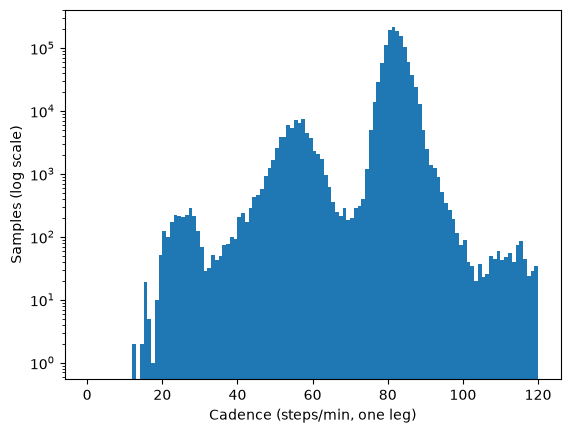

0.9900    4.348000
0.9990    5.160000
0.9999    6.188074
Name: speed_ms, dtype: float64


In [6]:
import matplotlib.pyplot as plt

cad = samples.loc[~no_cadence, "cadence"]
cad.plot.hist(bins=range(0, 121))
plt.yscale("log")
plt.xlabel("Cadence (steps/min, one leg)")
plt.ylabel("Samples (log scale)")
plt.show()

print(samples.loc[~no_cadence, "speed_ms"].quantile([.99, .999, .9999]))

In [7]:
walking = samples["cadence"] < 67
drop = no_cadence | no_speed | walking | first_60

print(f"walking (<67): {walking.sum():,}")
print(f"dropping total: {drop.sum():,} rows ({drop.mean():.1%})")

clean = samples.loc[~drop].copy()
print(clean.shape, clean["activity_id"].nunique(), "activities")

walking (<67): 93,089
dropping total: 116,383 rows (8.8%)
(1208740, 10) 408 activities


In [8]:
clean["dt"] = clean.groupby("activity_id")["timestamp"].diff().dt.total_seconds()
nominal = clean.groupby("activity_id")["dt"].transform("median")

clean["gap"] = clean["dt"] > 30
step = clean["dt"].clip(upper=nominal).fillna(0)
clean["moving_s"] = step.groupby(clean["activity_id"]).cumsum()

In [9]:
print(clean["gap"].sum(), "gaps in", clean.loc[clean["gap"], "activity_id"].nunique(), "activities")
clean.groupby("activity_id")["moving_s"].max().sort_values().tail(3)

844 gaps in 227 activities


activity_id
19272914242    10895.0
17414594839    13198.0
16663372714    13635.0
Name: moving_s, dtype: float64

In [10]:
summary = pd.read_parquet("../data/processed/activity_summary.parquet")
summary["qc_moving_s"] = summary["wall_clock_s"] - summary["paused_s"]

surviving = clean.groupby("activity_id")["moving_s"].max()
retained = surviving / summary.set_index("activity_id")["qc_moving_s"]

keep_ids = surviving[surviving >= 600].index
clean = clean[clean["activity_id"].isin(keep_ids)].copy()
clean["retained"] = clean["activity_id"].map(retained)

print(f"kept {len(keep_ids)} of {surviving.size} activities, {len(clean):,} rows")
print(clean.groupby("activity_id")["retained"].first().describe())

kept 403 of 408 activities, 1,207,543 rows
count    403.000000
mean       0.922374
std        0.087311
min        0.157430
25%        0.914969
50%        0.952305
75%        0.969128
max        0.989005
Name: retained, dtype: float64


In [15]:
clean["paused_before_s"] = clean["elapsed_s"] - clean["moving_s"]

In [11]:
nominal_by_act = clean.groupby("activity_id")["dt"].median()
one_hz = nominal_by_act[nominal_by_act <= 1.5].index
clean["is_1hz"] = clean["activity_id"].isin(one_hz)

med5 = (clean.groupby("activity_id")["speed_ms"]
             .transform(lambda s: s.rolling(5, center=True, min_periods=1).median()))

clean["speed_filt"] = clean["speed_ms"].where(~clean["is_1hz"], med5)

changed = (clean["speed_ms"] - clean["speed_filt"]).abs()
print(f"{(changed > 0.5).sum():,} samples moved >0.5 m/s")
print(f"unfiltered activities (6 s sampling): {(~clean['is_1hz']).groupby(clean['activity_id']).first().sum()}")

1,159 samples moved >0.5 m/s
unfiltered activities (6 s sampling): 7


In [19]:
import numpy as np

clean["win"] = (clean["moving_s"] // 30).astype(int)

g = clean.groupby(["activity_id", "win"])
windows = pd.DataFrame({
    "n":            g.size(),
    "has_gap":      g["gap"].any(),
    "speed_ms":     g["speed_filt"].mean(),
    "cadence":      g["cadence"].mean(),
    "hr":           g["heart_rate"].mean(),
    "alt_delta_m":  g["altitude_m"].last() - g["altitude_m"].first(),
    "dist_delta_m": g["distance_m"].last() - g["distance_m"].first(),
    "frac_cadence": g["fractional_cadence"].mean(),
    "garmin_sl_mm": g["garmin_step_length_mm"].mean(),
    "paused_before_s": g["paused_before_s"].min(),
    "moving_s":     g["moving_s"].min(),
    "is_1hz":       g["is_1hz"].first(),
    "retained":     g["retained"].first(),
}).reset_index()

expected = np.where(windows["is_1hz"], 30, 5)
windows["complete"] = windows["n"] >= 0.8 * expected

print(len(windows), "windows total")
print((~windows["complete"]).sum(), "incomplete")
print(windows["has_gap"].sum(), "span a gap")


40759 windows total
312 incomplete
750 span a gap


In [20]:
windows["step_freq_spm"] = (windows["cadence"] + windows["frac_cadence"]) * 2
windows["step_len_m"]    = windows["speed_ms"] / (windows["step_freq_spm"] / 60)
windows["grad_pct"] = 100 * windows["alt_delta_m"] / windows["dist_delta_m"]

print(windows["step_len_m"].describe(percentiles=[.01, .5, .99]))
print(windows["step_freq_spm"].describe(percentiles=[.01, .5, .99]))

bad = (windows["step_len_m"] < 0.5) | (windows["step_len_m"] > 2.5)
print(f"\noutside 0.5-2.5 m: {bad.sum()}")
print(f"  below 0.5: {(windows['step_len_m'] < 0.5).sum()}")
print(f"  above 2.5: {(windows['step_len_m'] > 2.5).sum()}")

ok = windows["garmin_sl_mm"].notna()
diff = windows.loc[ok, "step_len_m"] * 1000 - windows.loc[ok, "garmin_sl_mm"]
print(f"\nvs Garmin (mm), n={ok.sum()}: median {diff.median():.1f}, "
      f"5th {diff.quantile(.05):.1f}, 95th {diff.quantile(.95):.1f}")

count    40700.000000
mean         1.071332
std          0.131793
min          0.100746
1%           0.810018
50%          1.053648
99%          1.511907
max          1.831291
Name: step_len_m, dtype: float64
count    40700.000000
mean       163.957039
std          4.735053
min        146.366667
1%         153.033000
50%        163.666667
99%        176.600000
max        230.066667
Name: step_freq_spm, dtype: float64

outside 0.5-2.5 m: 14
  below 0.5: 14
  above 2.5: 0

vs Garmin (mm), n=40313: median -2.6, 5th -22.5, 95th 8.8


In [21]:
summary = pd.read_parquet("../data/processed/activity_summary.parquet")
summary["start_time"] = pd.to_datetime(summary["start_time"])
summary["year"] = summary["start_time"].dt.year

keep = (windows["complete"]
        & windows["step_len_m"].between(0.5, 2.5)
        & windows["step_len_m"].notna())

W = windows[keep].merge(
    summary[["activity_id", "start_time", "year"]], on="activity_id", how="left")

W.to_parquet("../data/processed/windows.parquet", index=False)

print(f"{len(W):,} windows from {W['activity_id'].nunique()} activities")
print(W.groupby("year").size())
print(f"{W['has_gap'].sum()} windows span a gap")

40,376 windows from 402 activities
year
2021       62
2023     3121
2024    12314
2025    15742
2026     9137
dtype: int64
736 windows span a gap


In [22]:
W = pd.read_parquet("../data/processed/windows.parquet")

W["log_v"] = np.log(W["speed_ms"])
W["log_L"] = np.log(W["step_len_m"])
W["log_f"] = np.log(W["step_freq_spm"] / 60)

print("max identity error:", (W["log_v"] - (W["log_f"] + W["log_L"])).abs().max())

D = W.dropna(subset=["grad_pct"]).copy()
print(len(D), "windows with gradient,", D["activity_id"].nunique(), "activities")

max identity error: 2.220446049250313e-16
37315 windows with gradient, 370 activities


In [23]:
import statsmodels.formula.api as smf

def fit(df, y):
    return smf.ols(f"{y} ~ log_v + grad_pct", data=df).fit(
        cov_type="cluster", cov_kwds={"groups": df["activity_id"]})

mL, mf = fit(D, "log_L"), fit(D, "log_f")

print(f"beta_L = {mL.params['log_v']:.4f}  (SE {mL.bse['log_v']:.4f})")
print(f"beta_f = {mf.params['log_v']:.4f}  (SE {mf.bse['log_v']:.4f})")
print(f"sum    = {mL.params['log_v'] + mf.params['log_v']:.10f}")
print(f"gradient coefficients sum to {mL.params['grad_pct'] + mf.params['grad_pct']:.2e}")

beta_L = 0.8781  (SE 0.0062)
beta_f = 0.1219  (SE 0.0062)
sum    = 1.0000000000
gradient coefficients sum to 5.64e-18


In [24]:
D["yr"] = D["year"].astype(str)
DY = D[D["year"] >= 2023].copy()      # 2021 is 2 activities, context only

def year_test(df, label):
    m = smf.ols("log_L ~ log_v*C(yr) + grad_pct", data=df).fit(
        cov_type="cluster", cov_kwds={"groups": df["activity_id"]})
    terms = [k for k in m.params.index if "log_v:" in k]
    ft = m.f_test(" = 0, ".join(terms) + " = 0")
    print(f"{label}: n={len(df)}  F={float(ft.fvalue):.2f}  p={float(ft.pvalue):.4f}")
    return m

year_test(DY, "all speeds")

lo = DY.groupby("year")["speed_ms"].quantile(.05).max()
hi = DY.groupby("year")["speed_ms"].quantile(.95).min()
print(f"common support: {lo:.2f}-{hi:.2f} m/s")

matched = DY[DY["speed_ms"].between(lo, hi)].copy()
year_test(matched, "common range")

for label, df in [("all", DY), ("matched", matched)]:
    print(f"\n{label}:")
    for yr, d in df.groupby("year"):
        m = smf.ols("log_L ~ log_v + grad_pct", data=d).fit(
            cov_type="cluster", cov_kwds={"groups": d["activity_id"]})
        print(f"  {yr}: {m.params['log_v']:.4f} (SE {m.bse['log_v']:.4f})")

all speeds: n=37253  F=3.15  p=0.0249
common support: 2.53-3.49 m/s
common range: n=30076  F=1.84  p=0.1391

all:
  2023: 0.8752 (SE 0.0072)
  2024: 0.8935 (SE 0.0073)
  2025: 0.8925 (SE 0.0112)
  2026: 0.8561 (SE 0.0151)

matched:
  2023: 0.8978 (SE 0.0176)
  2024: 0.8861 (SE 0.0110)
  2025: 0.8953 (SE 0.0121)
  2026: 0.8473 (SE 0.0205)


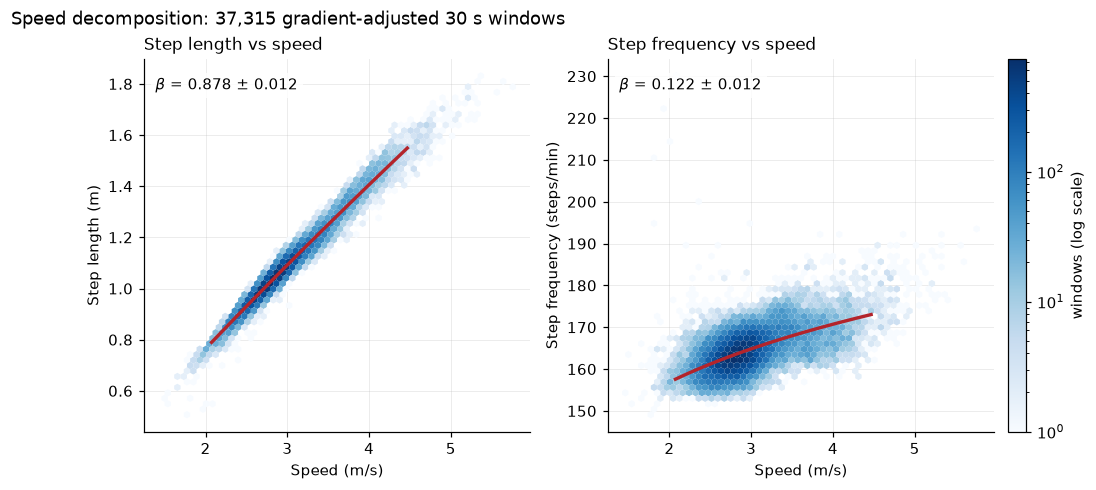

In [25]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True,
})

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), sharex=True)
vv = np.linspace(D["speed_ms"].quantile(.005), D["speed_ms"].quantile(.995), 200)
gbar = D["grad_pct"].mean()

for ax, m, col, lab, unit in [
        (axes[0], mL, "step_len_m",   "Step length",    "m"),
        (axes[1], mf, "step_freq_spm", "Step frequency", "steps/min")]:
    hb = ax.hexbin(D["speed_ms"], D[col], gridsize=55, bins="log",
                   cmap="Blues", mincnt=1, linewidths=0)
    pred = np.exp(m.params["Intercept"] + m.params["log_v"] * np.log(vv)
                  + m.params["grad_pct"] * gbar)
    if col == "step_freq_spm":
        pred = pred * 60
    ax.plot(vv, pred, color="#B3242B", lw=2.2, zorder=5)
    ax.set_xlabel("Speed (m/s)"); ax.set_ylabel(f"{lab} ({unit})")
    ax.set_title(f"{lab} vs speed", loc="left", fontsize=11)
    ax.text(.03, .95, rf"$\beta$ = {m.params['log_v']:.3f} ± {1.96*m.bse['log_v']:.3f}",
            transform=ax.transAxes, va="top", fontsize=10,
            bbox=dict(fc="white", ec="none", alpha=.8, pad=3))

fig.colorbar(hb, ax=axes, label="windows (log scale)", pad=.015, fraction=.035)
fig.suptitle(f"Speed decomposition: {len(D):,} gradient-adjusted 30 s windows",
             x=.01, ha="left", fontsize=12)
fig.savefig("../figures/fig01_02_decomposition.png", bbox_inches="tight")

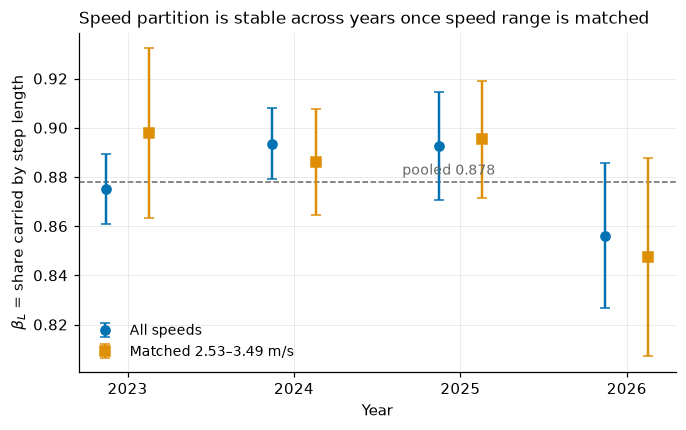

In [26]:
def per_year(df):
    out = {}
    for yr, d in df.groupby("year"):
        m = smf.ols("log_L ~ log_v + grad_pct", data=d).fit(
            cov_type="cluster", cov_kwds={"groups": d["activity_id"]})
        out[yr] = (m.params["log_v"], 1.96 * m.bse["log_v"])
    return out

A, M = per_year(DY), per_year(matched)

fig, ax = plt.subplots(figsize=(7.0, 4.0))
yrs = sorted(A); x = np.arange(len(yrs)); off = 0.13

for dat, dx, c, lab, mk in [
        (A, -off, "#0173B2", "All speeds", "o"),
        (M, +off, "#DE8F05", f"Matched {lo:.2f}\u2013{hi:.2f} m/s", "s")]:
    ax.errorbar(x + dx, [dat[y][0] for y in yrs], yerr=[dat[y][1] for y in yrs],
                fmt=mk, ms=6, capsize=3, lw=1.6, color=c, label=lab)

pool = mL.params["log_v"]
ax.axhline(pool, color="#666", ls="--", lw=1, zorder=0)
ax.text(0.62, pool + .0015, f"pooled {pool:.3f}", fontsize=9, color="#666",
        transform=ax.get_yaxis_transform(), ha="center", va="bottom")
ax.set_xticks(x); ax.set_xticklabels(yrs)
ax.set_ylabel(r"$\beta_L$ = share carried by step length")
ax.set_xlabel("Year")
ax.set_title("Speed partition is stable across years once speed range is matched",
             loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="lower left")
fig.savefig("../figures/fig03_partition_by_year.png", bbox_inches="tight")